# Evaluation Plots

Vision: 

```
from ocean_emulators.plotting import eval_plots

training_url = ...
prediction_url = ...

eval_plots(training_url, prediction_url)
```

Where

```
def eval_plots(...):
    # Run tests on prediction data
    # Plot all relevant panels in a neat and organized way
```


In [1]:
import xarray as xr

In [2]:
# from ocean_emulators.postprocessing import post_processor, prediction_data_test
import xarray as xr


def post_processor(ds: xr.Dataset) -> xr.Dataset:
    """Converts the prediction output to an xarray dataset with the same dimensions/variables as input"""
    da = ds["__xarray_dataarray_variable__"]
    n_lev = 19
    variables = ["uo", "vo", "thetao", "so"]
    slices = [slice(i, i + n_lev) for i in range(0, len(variables) * n_lev, n_lev)]
    var_slices = {k: sl for k, sl in zip(variables, slices)}
    variables = {
        k: da.isel(var=sl).rename({"var": "lev"}) for k, sl in var_slices.items()
    }
    variables["zos"] = da.isel(var=-1).squeeze()
    return xr.Dataset(variables)


def prediction_data_test(ds_prediction: xr.Dataset, ds_input):
    """Testfunction to check post-processed prediction output for format"""
    # TODO: Run the test for the preprocessing data here and warn only if it fails
    # That data should have been checked before training and here we only strictly enforce that things reflect the state of the input data.

    expected_sizes = {"x": 360, "y": 180, "lev": 19}
    given_sizes = ds_prediction.sizes
    compare_dims = list(
        set(list(expected_sizes.keys()) + list(given_sizes.keys())) - set(["time"])
    )
    if any(expected_sizes[dim] != given_sizes[dim] for dim in compare_dims):
        raise ValueError(
            f"Input dataset does not have the right sizes. Expected{expected_sizes}, got {given_sizes}"
        )

    # ensure all dimensions have coordinate values
    dims_without_coords = [
        di for di in ds_prediction.dims if di not in ds_prediction.coords
    ]
    if len(dims_without_coords) > 0:
        raise ValueError(
            f"Found the following dimensions without coordinates: {dims_without_coords}"
        )

    # ensure the attributes are the same on both datasets
    if not ds_prediction.attrs == ds_input.attrs:
        raise ValueError(
            "Prediction and Input datasets do not have matching attributes"
        )

    # TODO: ensure that both arrays have the same coordinates


In [5]:
import os
ds_input = xr.open_zarr(
            os.path.join('/pscratch/sd/s/suryad/data', 'OM4_Horizontal_Regrid_Old.zarr')
        )

ds_prediction_raw = xr.open_zarr("/pscratch/sd/s/suryad/Ocean_Emulator/Preds/ConvNext UNet Train3DEval3DHist1_Train_global_3D_Test_global_3D_all_N_train_4000_Lateral_Data_025_no_smooth/Pred_lateral_Fast_Data_025_global_3D_all_N_samples_4000_rand_seed_1.zarr")

# our groundtruth is always just a time slice of the training (training is a bad name
ds_groundtruth = ds_input.isel(time=slice(4141, 4741))
# quick fix: 
ds_prediction_raw = ds_prediction_raw.assign_coords(time=ds_groundtruth.time)
# ds_prediction_raw = ds_prediction_raw.swap_dims({'x':'y'}) # why does this not work?
ds_prediction_raw = ds_prediction_raw.rename({'x':'x_i', 'y':'y_i'}).rename({'x_i':'y', 'y_i':'x'})
ds_prediction = post_processor(ds_prediction_raw) #FIXME: This should be done before uploading the prediction output.
# quick fix (coords to lev)
ds_prediction = ds_prediction.assign_coords(lev=range(len(ds_prediction.lev)), x=ds_input.x, y=ds_input.y)

# Run the test to make sure the output is formatted correctly
prediction_data_test(ds_prediction, ds_input)

In [6]:
import numpy as np
ds_raw = xr.DataArray(np.random.random([3,180, 360, 77]), dims=['time', 'y','x', 'var'])

In [7]:
# quickly calculate area (TODO: This should be a coordinate on the ds_training)
import numpy as np

area_weights = np.cos(np.deg2rad(ds_input.y))
# area_weights = xr.open_dataset("gs://leap-persistent/sd5313/grids_CM2x.zarr", engine='zarr', chunks={})['area_C']
# area_weights = (area_weights/area_weights.max()).load()

ds_prediction = ds_prediction.assign_coords(areacello=area_weights)
ds_input = ds_input.assign_coords(areacello=area_weights)
ds_groundtruth = ds_groundtruth.assign_coords(areacello=area_weights)

## TODO:
- add metrics (dz, area)
- Add coordinate values (from source dataset)
- Chunk better
- Add metadata

In [8]:
# for faster dev take only a smaller time range
time_slice = slice(0, 600)
ds_prediction = ds_prediction.isel(time=time_slice)
ds_groundtruth = ds_groundtruth.isel(time=time_slice)
display(ds_prediction)
ds_groundtruth

<xarray.Dataset>
Dimensions:    (time: 600, y: 180, x: 360, lev: 19)
Coordinates:
  * time       (time) object 2014-09-25 12:00:00 ... 2022-12-09 12:00:00
  * lev        (lev) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
    areacello  (y) float64 0.008727 0.02618 0.04362 ... 0.04362 0.02618 0.008727
Data variables:
    uo         (time, y, x, lev) float64 dask.array<chunksize=(75, 23, 45, 10), meta=np.ndarray>
    vo         (time, y, x, lev) float64 dask.array<chunksize=(75, 23, 45, 1), meta=np.ndarray>
    thetao     (time, y, x, lev) float64 dask.array<chunksize=(75, 23, 45, 2), meta=np.ndarray>
    so         (time, y, x, lev) float64 dask.array<chunksize=(75, 23, 45, 3), meta=np.ndarray>
    zos        (time, y, x) float64 dask.array<chunksize=(75, 23, 45), meta=np.ndarray>

<xarray.Dataset>
Dimensions:    (time: 600, y: 180, x: 360, lev: 19)
Coordinates:
  * time       (time) object 2014-09-25 12:00:00 ... 2022-12-09 12:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
    areacello  (y) float64 0.008727 0.02618 0.04362 ... 0.04362 0.02618 0.008727
Dimensions without coordinates: lev
Data variables:
    hfds       (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so         (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo      (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao     (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo         (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo         (time, lev, y, x) float64 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos        (time, y, x) float64 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>

In [9]:
def profile_mean(ds:xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).mean(['x','y'])

def profile_std(ds:xr.Dataset) -> xr.Dataset:
    return ds.weighted(ds.areacello).std(['x','y'])

In [10]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    profile_prediction = profile_mean(ds_prediction).load()
    profile_groundtruth = profile_mean(ds_groundtruth).load()
    profile_stdv_prediction = profile_std(ds_prediction).load()
    profile_stdv_groundtruth = profile_std(ds_groundtruth).load()

[########################################] | 100% Completed | 17.96 s
[########################################] | 100% Completed | 18.98 s
[########################################] | 100% Completed | 23.31 s
[########################################] | 100% Completed | 24.97 s


### Thetao

In [17]:
profile_groundtruth.thetao

<xarray.DataArray 'thetao' (time: 600, lev: 19)>
array([[18.55568254, 18.54521176, 18.37992323, ...,  1.10982228,
         0.85875556,  0.89234866],
       [18.52132209, 18.50976234, 18.36684662, ...,  1.10976503,
         0.858777  ,  0.89232644],
       [18.49661034, 18.48505675, 18.35569251, ...,  1.10974846,
         0.85879643,  0.89230021],
       ...,
       [18.46324264, 18.43829322, 18.25395334, ...,  1.10856607,
         0.8562241 ,  0.88723672],
       [18.46025382, 18.44123277, 18.26849134, ...,  1.10855339,
         0.85621015,  0.88722131],
       [18.46739915, 18.44543711, 18.27564899, ...,  1.10854898,
         0.85621035,  0.88720535]])
Coordinates:
  * time     (time) object 2014-09-25 12:00:00 ... 2022-12-09 12:00:00
Dimensions without coordinates: lev

In [11]:
profile_groundtruth.thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [18]:
profile_prediction.thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [19]:
(profile_prediction-profile_groundtruth).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [20]:
ref_std = profile_stdv_groundtruth.mean('time')
((profile_prediction-profile_groundtruth)/ref_std).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [21]:
(profile_prediction-profile_prediction.mean('time')).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [22]:
(profile_groundtruth-profile_groundtruth.mean('time')).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [23]:
(profile_groundtruth-profile_groundtruth.mean('time')).isel(time=slice(None,4141)).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [24]:
(profile_groundtruth-profile_groundtruth.mean('time')).isel(time=slice(None,4000)).thetao.plot(x='time', yincrease=False)

ImportError: Plotting of arrays of cftime.datetime objects or arrays indexed by cftime.datetime objects requires the optional `nc-time-axis` (v1.2.0 or later) package.

In [1]:
(profile_groundtruth).isel(lev=0).thetao.plot(x='time')

NameError: name 'profile_groundtruth' is not defined

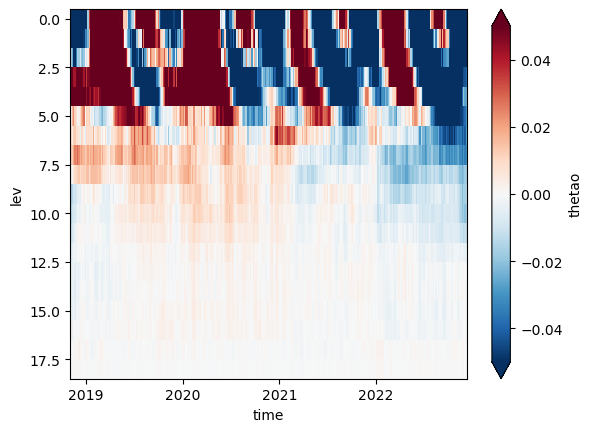

In [67]:
(profile_prediction-profile_prediction.mean('time')).thetao.plot(x='time', yincrease=False, vmax=0.05)

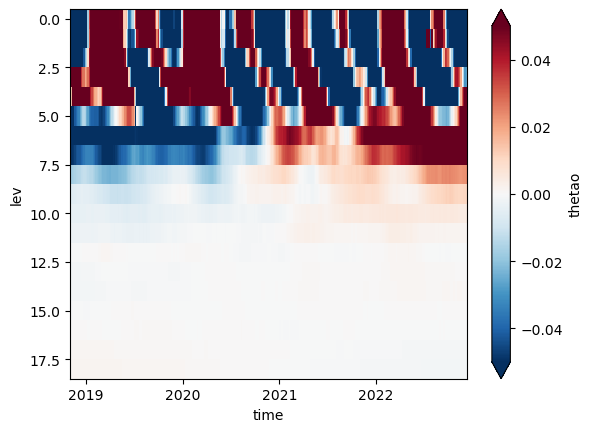

In [68]:
(profile_groundtruth-profile_groundtruth.mean('time')).thetao.plot(x='time', yincrease=False, vmax=0.05)

### Salinity

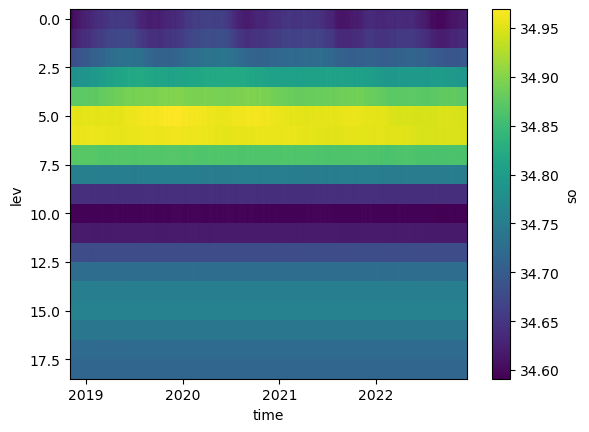

In [69]:
profile_prediction.so.plot(x='time', yincrease=False)

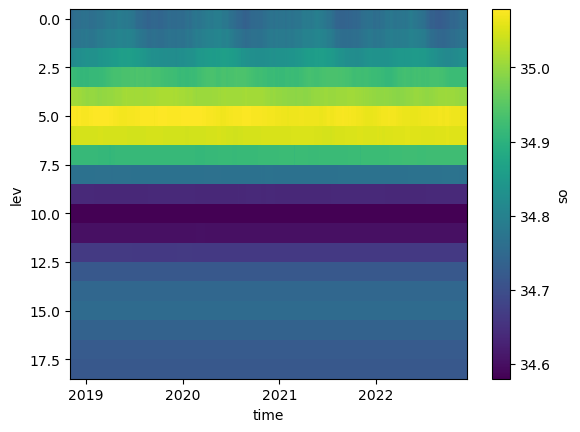

In [70]:
profile_groundtruth.so.plot(x='time', yincrease=False)

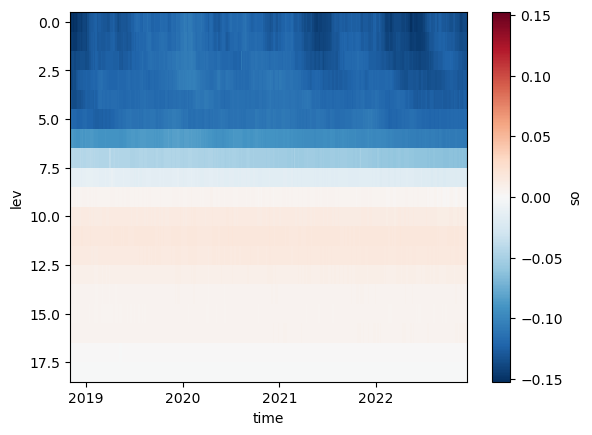

In [71]:
(profile_prediction-profile_groundtruth).so.plot(x='time', yincrease=False)

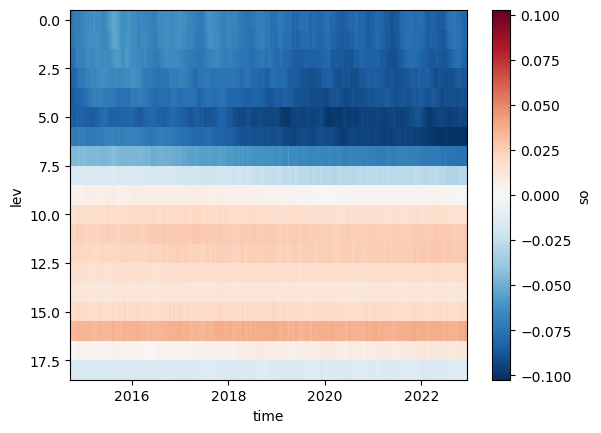

In [49]:
ref_std = profile_stdv_groundtruth.mean('time')
((profile_prediction-profile_groundtruth)/ref_std).so.plot(x='time', yincrease=False)

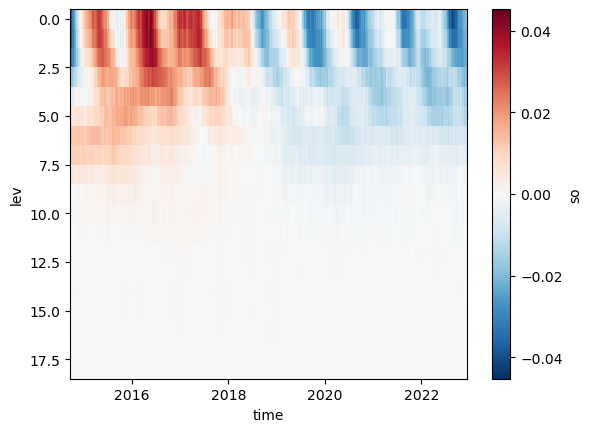

In [50]:
(profile_prediction-profile_prediction.mean('time')).so.plot(x='time', yincrease=False)

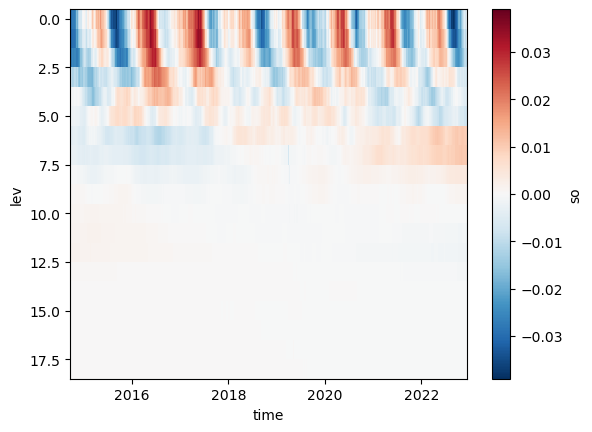

In [51]:
(profile_groundtruth-profile_groundtruth.mean('time')).so.plot(x='time', yincrease=False)

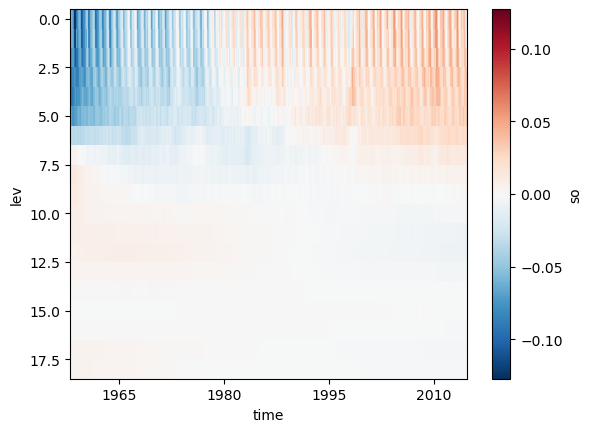

In [11]:
(profile_groundtruth-profile_groundtruth.mean('time')).isel(time=slice(None,4141)).so.plot(x='time', yincrease=False)

### Metrics

In [96]:
mse = ((((ds_prediction - ds_groundtruth)**2).mean())**(1/2)).load()

/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(
/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(
/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(
/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 75
  result = blockwise(
/srv/conda/envs/notebook/lib/python3.11/site-packages/dask/array/core.py:4832: PerformanceWarning: Increasing number of chunks by factor of 64
  result = blockwise(


In [97]:
mse

<xarray.Dataset> Size: 40B
Dimensions:  ()
Data variables:
    uo       float64 8B 0.04853
    vo       float64 8B 0.04463
    thetao   float64 8B 0.5248
    so       float64 8B 0.1634
    zos      float64 8B 0.06494

## Seasonal maps

In [52]:
def seasonal_composite(ds:xr.Dataset) -> xr.Dataset:
    # maybe use flox?
    return ds.groupby('time.season').mean('time')

In [53]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    seasonal_prediction = seasonal_composite(ds_prediction).load()
    seasonal_groundtruth = seasonal_composite(ds_groundtruth).load()

[########################################] | 100% Completed | 407.66 s
[########################################] | 100% Completed | 76.34 s


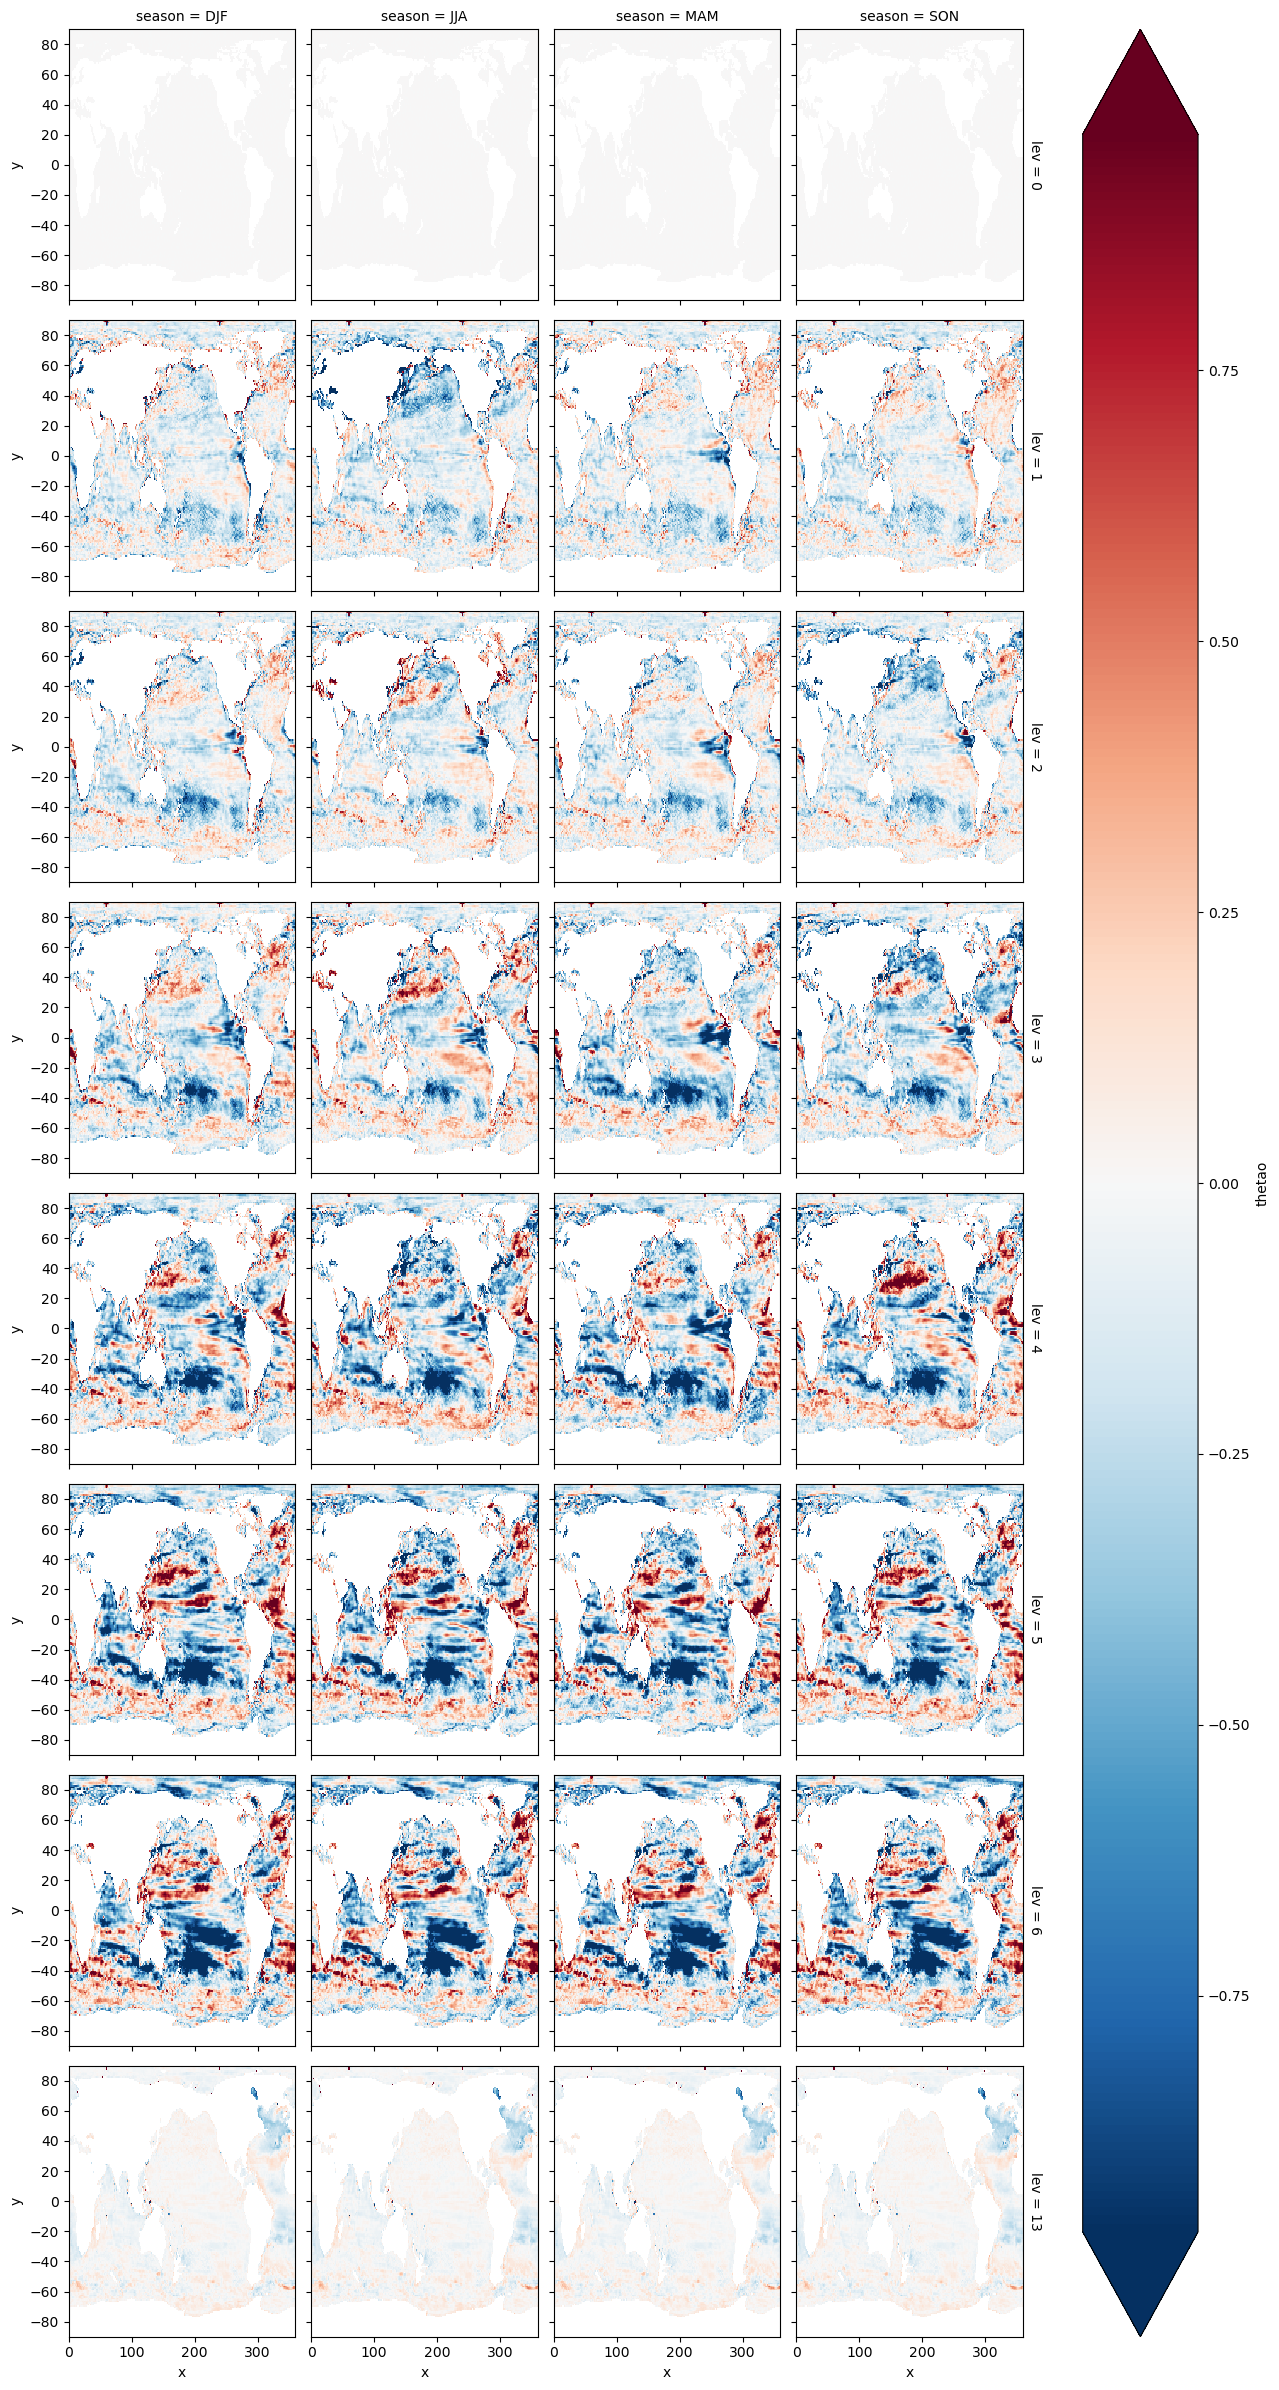

In [54]:
(seasonal_prediction-seasonal_groundtruth).isel(lev=[0, 1 , 2, 3, 4 ,5 , 6, 13]).thetao.plot(col='season', row='lev', robust=True)